Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading models...
✅ XGBoost loaded
✅ Scaler loaded
✅ Label encoder loaded
   Classes: [np.str_('Analysis'), np.str_('Backdoor'), np.str_('Bot'), np.str_('Brute Force'), np.str_('DDoS'), np.str_('DoS'), np.str_('Exploits'), np.str_('Fuzzers'), np.str_('Generic'), np.str_('Infilteration'), np.str_('Reconnaissance'), np.str_('Shellcode'), np.str_('Theft'), np.str_('Worms'), np.str_('injection'), np.str_('mitm'), np.str_('password'), np.str_('ransomware'), np.str_('scanning'), np.str_('xss')]
✅ CNN-LSTM loaded

── Stage 1: XGBoost Binary Detection ──
Counting attack rows...
Total rows   : 22,796,391
Total attacks: 15,062,631

Running XGBoost + saving attack rows to disk...
  Chunk 1 | Processed: 500,000 | Attacks written: 232,824
  Chunk 2 | Processed: 1,000,000 | Attacks written: 534,276
  Chunk 3 | Processed: 1,500,000 | Attacks written: 896,017
  Chunk 4 | Pro

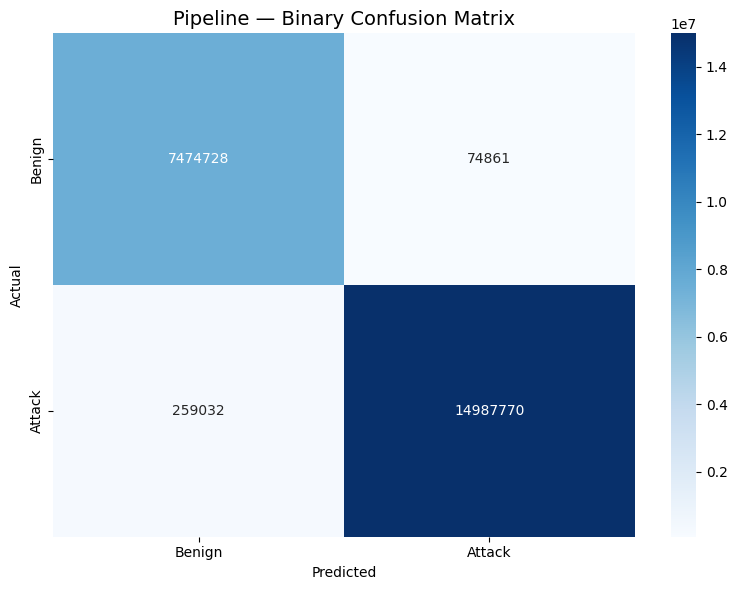

Binary confusion matrix saved.


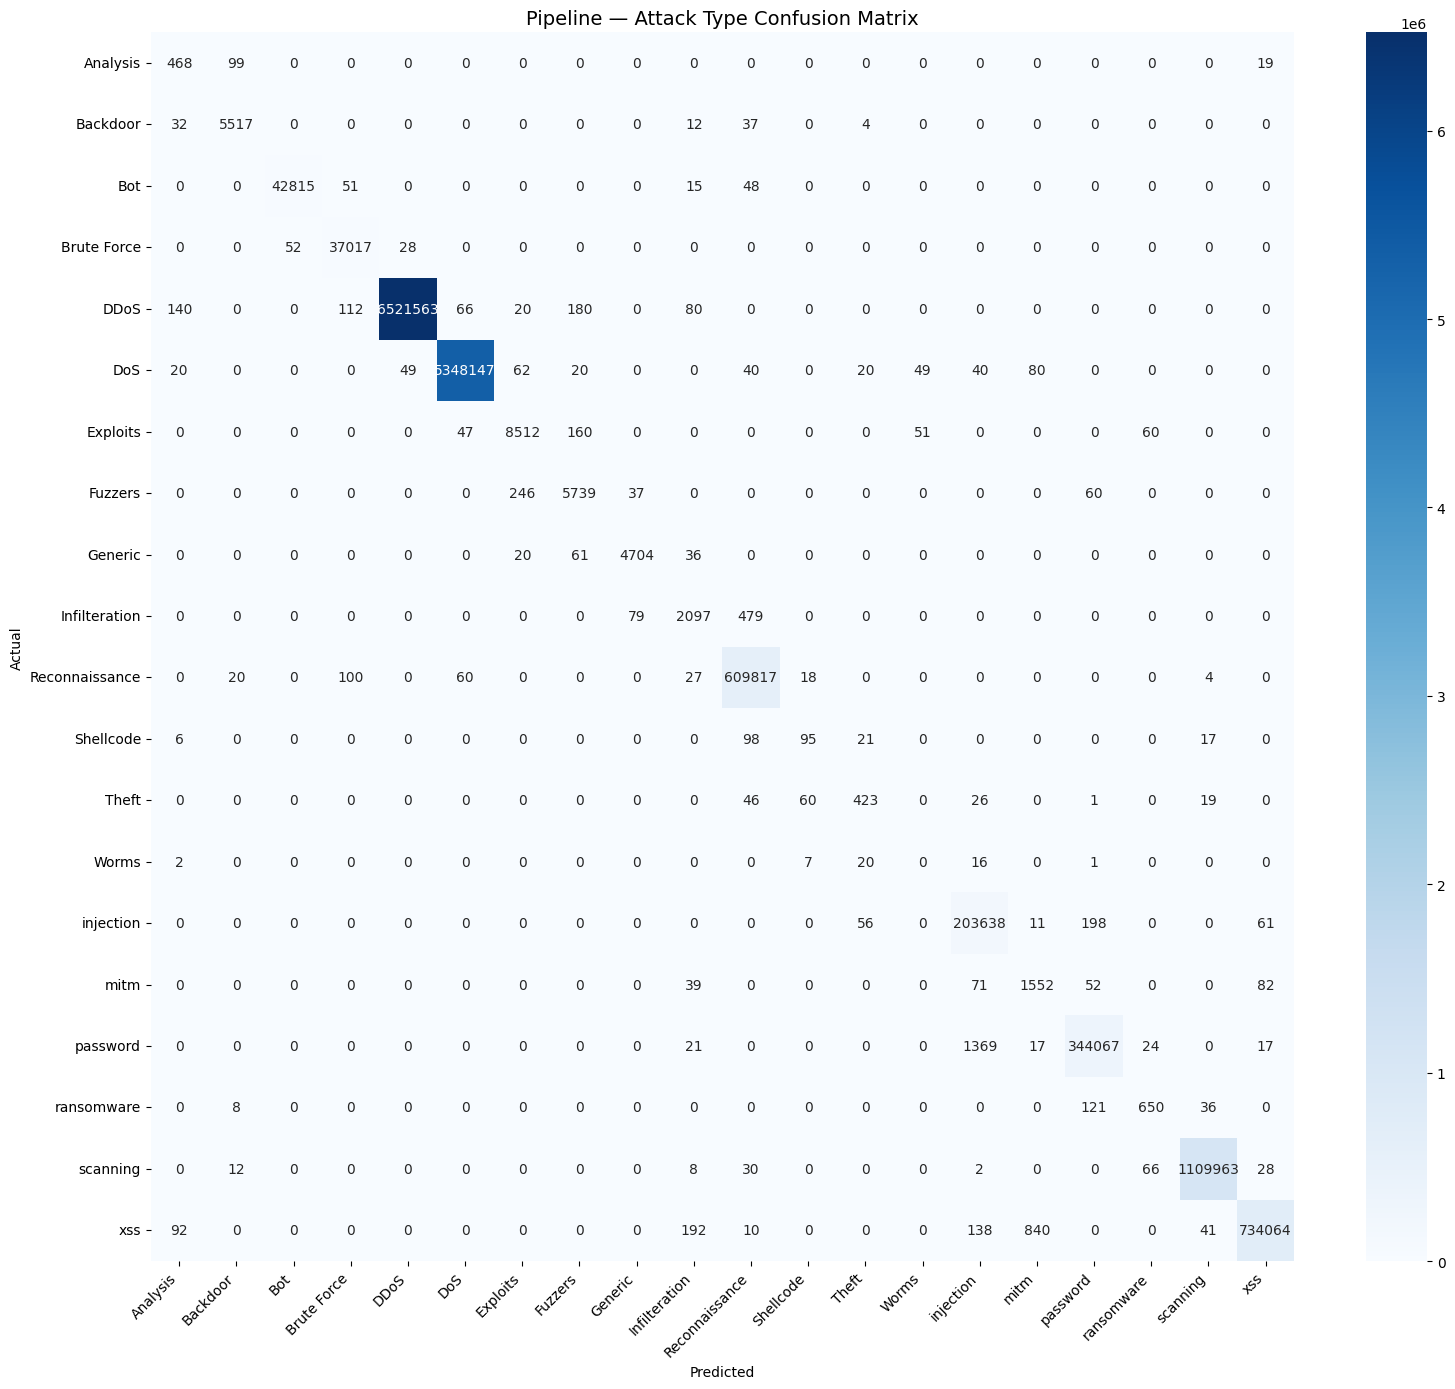

Attack type confusion matrix saved.


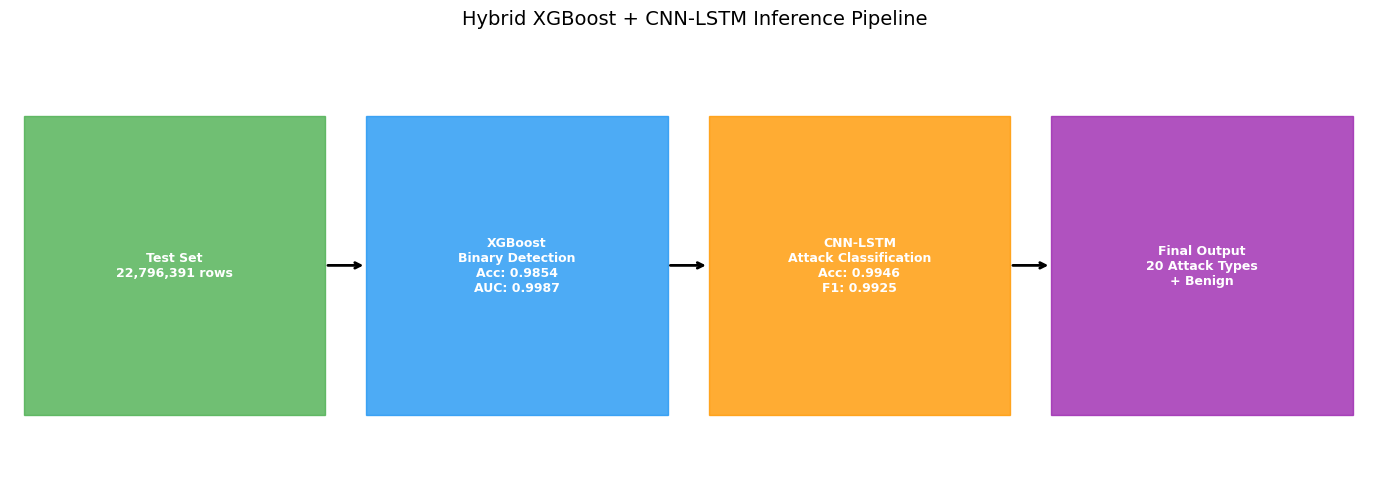

Pipeline diagram saved.

✅ Inference pipeline complete. All outputs saved to Drive.


In [1]:
# ============================================================
# 03_inference_pipeline.ipynb
# End-to-End Inference: XGBoost → CNN-LSTM
# RAM-safe version
# ============================================================

# ── CELL 1: Mount Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
import os
os.environ['KERAS_BACKEND'] = 'jax'
!pip install keras jax[tpu] -q -f https://storage.googleapis.com/jax-releases/libtpu_releases.html

# ── CELL 2: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
import time
import keras

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# ── CELL 3: Paths & Config ───────────────────────────────────
test_csv    = "/content/drive/MyDrive/EPdataset/stratified_splits/test.csv"
xgb_dir     = "/content/drive/MyDrive/EPdataset/models/xgboost"
cnnlstm_dir = "/content/drive/MyDrive/EPdataset/models/cnnlstm"
plots_dir   = "/content/drive/MyDrive/EPdataset/plots/pipeline"
os.makedirs(plots_dir, exist_ok=True)

# Local disk paths for attack buffer
attack_X_path    = "/content/attack_X.npy"
attack_true_path = "/content/attack_true.npy"

FEATURES = [
    'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'L4_DST_PORT', 'ICMP_TYPE', 'DNS_QUERY_TYPE', 'DNS_QUERY_ID',
    'FTP_COMMAND_RET_CODE'
]
SEQ_LEN    = 20
BATCH_SIZE = 64
THRESHOLD  = 0.5
CHUNK_SIZE = 500_000
CNN_CHUNK  = SEQ_LEN * 2000  # 40,000 rows per CNN batch

# ── CELL 4: Load Models ──────────────────────────────────────
print("Loading models...")

xgb_booster = xgb.Booster()
xgb_booster.load_model(os.path.join(xgb_dir, 'xgboost_model.json'))
print("✅ XGBoost loaded")

with open(os.path.join(xgb_dir, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
print("✅ Scaler loaded")

with open(os.path.join(cnnlstm_dir, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)
print(f"✅ Label encoder loaded")
print(f"   Classes: {list(label_encoder.classes_)}")

cnnlstm_model = keras.models.load_model(
    os.path.join(cnnlstm_dir, 'best_model.keras')
)
print("✅ CNN-LSTM loaded")

# ── CELL 5: Stage 1 — XGBoost Inference ─────────────────────
# Process test set chunk by chunk
# Save attack rows directly to local disk as memmap
# This avoids building large lists in RAM

print("\n── Stage 1: XGBoost Binary Detection ──")

# First pass — count total attack rows to preallocate memmap
print("Counting attack rows...")
total_rows   = 0
total_attack = 0

for chunk in pd.read_csv(test_csv, chunksize=CHUNK_SIZE, low_memory=False):
    X       = scaler.transform(chunk[FEATURES])
    dmatrix = xgb.DMatrix(X)
    proba   = xgb_booster.predict(dmatrix)
    pred    = (proba >= THRESHOLD).astype(int)
    total_rows   += len(chunk)
    total_attack += pred.sum()
    del X, dmatrix, proba, pred, chunk

print(f"Total rows   : {total_rows:,}")
print(f"Total attacks: {total_attack:,}")

# Preallocate memmap files on local disk
attack_X_mm    = np.lib.format.open_memmap(
    attack_X_path, mode='w+',
    dtype=np.float32,
    shape=(total_attack, len(FEATURES))
)
attack_true_mm = np.lib.format.open_memmap(
    attack_true_path, mode='w+',
    dtype='U20',
    shape=(total_attack,)
)

# Second pass — XGBoost inference + save attack rows to memmap
print("\nRunning XGBoost + saving attack rows to disk...")

y_true_binary_all = []
y_pred_binary_all = []
xgb_proba_all     = []
write_idx         = 0
xgb_time_total    = 0
processed         = 0

for i, chunk in enumerate(pd.read_csv(
        test_csv, chunksize=CHUNK_SIZE, low_memory=False)):

    X       = scaler.transform(chunk[FEATURES])
    dmatrix = xgb.DMatrix(X)

    t0    = time.time()
    proba = xgb_booster.predict(dmatrix)
    pred  = (proba >= THRESHOLD).astype(int)
    xgb_time_total += time.time() - t0

    y_true_binary_all.extend(chunk['Label'].values.tolist())
    y_pred_binary_all.extend(pred.tolist())
    xgb_proba_all.extend(proba.tolist())

    # Write attack rows directly to memmap
    attack_mask = pred == 1
    n_attacks   = attack_mask.sum()
    if n_attacks > 0:
        attack_X_mm[write_idx:write_idx + n_attacks] = \
            X[attack_mask].astype(np.float32)
        attack_true_mm[write_idx:write_idx + n_attacks] = \
            chunk['Attack'].values[attack_mask]
        write_idx += n_attacks

    processed += len(chunk)
    print(f"  Chunk {i+1} | Processed: {processed:,} | "
          f"Attacks written: {write_idx:,}")

    del X, dmatrix, proba, pred, chunk

# Flush memmap to disk
attack_X_mm.flush()
attack_true_mm.flush()
print(f"\nXGBoost done in {xgb_time_total:.2f}s")

# XGBoost metrics
y_true_binary = np.array(y_true_binary_all)
y_pred_binary = np.array(y_pred_binary_all)
xgb_proba     = np.array(xgb_proba_all)
del y_true_binary_all, y_pred_binary_all, xgb_proba_all

bin_acc  = accuracy_score(y_true_binary, y_pred_binary)
bin_prec = precision_score(y_true_binary, y_pred_binary)
bin_rec  = recall_score(y_true_binary, y_pred_binary)
bin_f1   = f1_score(y_true_binary, y_pred_binary)
bin_auc  = roc_auc_score(y_true_binary, xgb_proba)

print(f"\nStage 1 — XGBoost Binary:")
print(f"  Accuracy  : {bin_acc:.4f}")
print(f"  Precision : {bin_prec:.4f}")
print(f"  Recall    : {bin_rec:.4f}")
print(f"  F1 Score  : {bin_f1:.4f}")
print(f"  AUC-ROC   : {bin_auc:.4f}")

# ── CELL 6: Stage 2 — CNN-LSTM Inference ─────────────────────
print(f"\n── Stage 2: CNN-LSTM Attack Classification ──")
print(f"Processing {write_idx:,} attack rows in batches of {CNN_CHUNK:,}...")

pred_labels    = []
true_labels    = []
cnn_time_total = 0

for start in range(0, write_idx, CNN_CHUNK):
    end = min(start + CNN_CHUNK, write_idx)

    # Load only this batch from memmap — minimal RAM
    X_chunk = np.array(attack_X_mm[start:end], dtype=np.float32)
    t_chunk = attack_true_mm[start:end]

    n_sequences = len(X_chunk) // SEQ_LEN
    if n_sequences == 0:
        del X_chunk
        continue

    remainder = len(X_chunk) % SEQ_LEN
    X_seq     = X_chunk[:n_sequences * SEQ_LEN].reshape(
                    n_sequences, SEQ_LEN, len(FEATURES))

    t0    = time.time()
    proba = cnnlstm_model.predict(X_seq, batch_size=BATCH_SIZE, verbose=0)
    cnn_time_total += time.time() - t0

    pred_seq  = np.argmax(proba, axis=1)
    pred_rows = np.repeat(pred_seq, SEQ_LEN)

    if remainder > 0:
        pred_rows = np.concatenate([
            pred_rows, np.full(remainder, pred_seq[-1])
        ])

    pred_labels.extend(
        label_encoder.inverse_transform(pred_rows).tolist()
    )
    true_labels.extend(t_chunk[:len(pred_rows)].tolist())

    del X_chunk, X_seq, proba, pred_seq, pred_rows
    print(f"  CNN batch {start//CNN_CHUNK + 1} | "
          f"Processed: {end:,} / {write_idx:,}")

# Clean up memmap files
del attack_X_mm, attack_true_mm
os.remove(attack_X_path)
os.remove(attack_true_path)

print(f"\nCNN-LSTM done in {cnn_time_total:.2f}s")

# ── CELL 7: Metrics ──────────────────────────────────────────
mc_acc  = accuracy_score(true_labels, pred_labels)
mc_prec = precision_score(true_labels, pred_labels,
                          average='weighted', zero_division=0)
mc_rec  = recall_score(true_labels, pred_labels,
                       average='weighted', zero_division=0)
mc_f1   = f1_score(true_labels, pred_labels,
                   average='weighted', zero_division=0)

total_time = xgb_time_total + cnn_time_total

print("\n========== Pipeline Evaluation ==========")
print(f"\nStage 1 — XGBoost Binary:")
print(f"  Accuracy  : {bin_acc:.4f}")
print(f"  Precision : {bin_prec:.4f}")
print(f"  Recall    : {bin_rec:.4f}")
print(f"  F1 Score  : {bin_f1:.4f}")
print(f"  AUC-ROC   : {bin_auc:.4f}")
print(f"  Time      : {xgb_time_total:.2f}s")

print(f"\nStage 2 — CNN-LSTM Multiclass:")
print(f"  Accuracy  : {mc_acc:.4f}")
print(f"  Precision : {mc_prec:.4f}")
print(f"  Recall    : {mc_rec:.4f}")
print(f"  F1 Score  : {mc_f1:.4f}")
print(f"  Time      : {cnn_time_total:.2f}s")

print(f"\nInference Speed:")
print(f"  Total rows : {total_rows:,}")
print(f"  Total time : {total_time:.2f}s")
print(f"  Rows/sec   : {total_rows/total_time:,.0f}")

print(f"\nClassification Report (Attack Types):")
print(classification_report(true_labels, pred_labels, zero_division=0))

# Save metrics
metrics_path = os.path.join(plots_dir, 'pipeline_metrics.txt')
with open(metrics_path, 'w') as f:
    f.write("========== Pipeline Evaluation ==========\n\n")
    f.write("Stage 1 — XGBoost Binary:\n")
    f.write(f"  Accuracy  : {bin_acc:.4f}\n")
    f.write(f"  Precision : {bin_prec:.4f}\n")
    f.write(f"  Recall    : {bin_rec:.4f}\n")
    f.write(f"  F1 Score  : {bin_f1:.4f}\n")
    f.write(f"  AUC-ROC   : {bin_auc:.4f}\n\n")
    f.write("Stage 2 — CNN-LSTM Multiclass:\n")
    f.write(f"  Accuracy  : {mc_acc:.4f}\n")
    f.write(f"  Precision : {mc_prec:.4f}\n")
    f.write(f"  Recall    : {mc_rec:.4f}\n")
    f.write(f"  F1 Score  : {mc_f1:.4f}\n\n")
    f.write(f"Total rows : {total_rows:,}\n")
    f.write(f"Total time : {total_time:.2f}s\n")
    f.write(f"Rows/sec   : {total_rows/total_time:,.0f}\n\n")
    f.write(classification_report(true_labels, pred_labels, zero_division=0))
print(f"Metrics saved.")

# ── CELL 8: Binary Confusion Matrix ──────────────────────────
cm_bin = confusion_matrix(y_true_binary, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Pipeline — Binary Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'binary_confusion_matrix.png'), dpi=150)
plt.show()
print("Binary confusion matrix saved.")

# ── CELL 9: Attack Type Confusion Matrix ─────────────────────
all_classes = list(label_encoder.classes_)
cm_mc = confusion_matrix(true_labels, pred_labels, labels=all_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues',
            xticklabels=all_classes,
            yticklabels=all_classes)
plt.title('Pipeline — Attack Type Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'attack_type_confusion_matrix.png'), dpi=150)
plt.show()
print("Attack type confusion matrix saved.")

# ── CELL 10: Pipeline Diagram ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

stages = [
    f"Test Set\n{total_rows:,} rows",
    f"XGBoost\nBinary Detection\nAcc: {bin_acc:.4f}\nAUC: {bin_auc:.4f}",
    f"CNN-LSTM\nAttack Classification\nAcc: {mc_acc:.4f}\nF1: {mc_f1:.4f}",
    f"Final Output\n{len(set(pred_labels))} Attack Types\n+ Benign"
]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

for i, (stage, color) in enumerate(zip(stages, colors)):
    ax.add_patch(plt.Rectangle(
        (i*0.25+0.01, 0.15), 0.22, 0.7,
        color=color, alpha=0.8,
        transform=ax.transAxes
    ))
    ax.text(i*0.25+0.12, 0.5, stage,
            ha='center', va='center',
            fontsize=9, fontweight='bold',
            color='white', transform=ax.transAxes)
    if i < len(stages) - 1:
        ax.annotate('',
            xy=((i+1)*0.25+0.01, 0.5),
            xytext=(i*0.25+0.23, 0.5),
            xycoords='axes fraction',
            textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black', lw=2)
        )

plt.title('Hybrid XGBoost + CNN-LSTM Inference Pipeline',
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'pipeline_diagram.png'), dpi=150)
plt.show()
print("Pipeline diagram saved.")

print("\n✅ Inference pipeline complete. All outputs saved to Drive.")